# Pipeline Inspection

For the inspection of saved files & method comparison

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  

import numpy as np
import pandas as pd

from src import io
import config

In [3]:
PID = "subject-1" 

## Step 1. cleaning (inspect)


`cleaned_data` created by `01_clean`

invalid %: 0.09913470783036


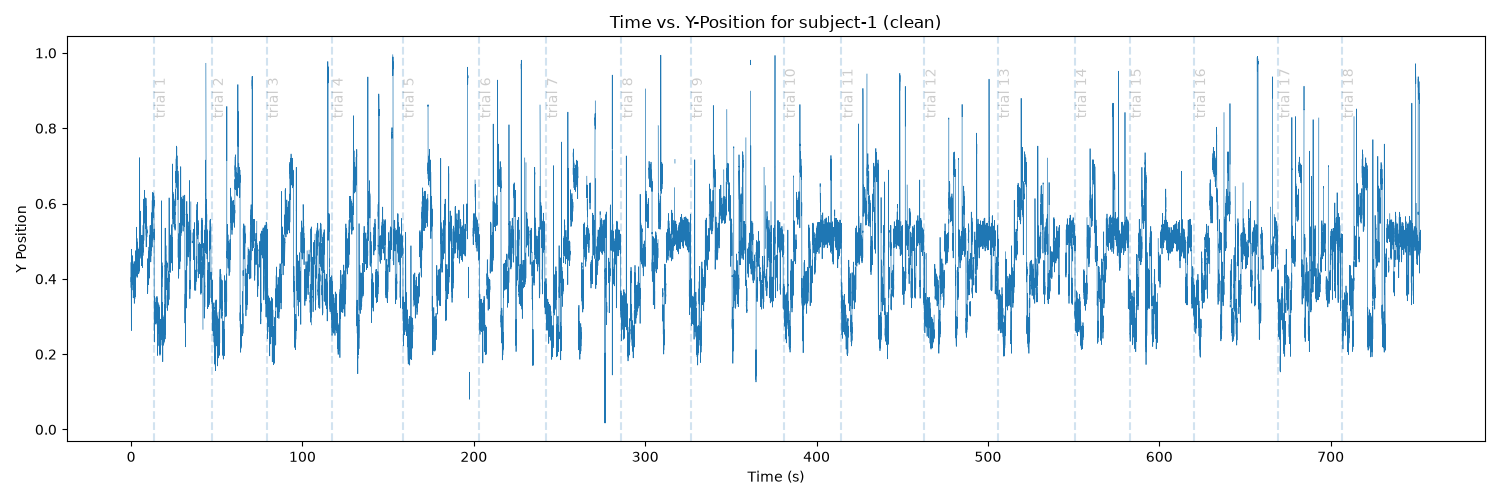

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Time vs. Y-Position for subject-1 (clean)'}, xlabel='Time (s)', ylabel='Y Position'>)

In [4]:
from src.visualization import plot_gaze_across_time

clean = io.load_checkpoint("clean_samples", PID)
print("invalid %:", io.load_stats(PID, "01_clean").get("invalid_pct"))

plot_gaze_across_time(clean, "Y", PID, note="(clean)", show=True)


In [5]:
# load filtered event
event = io.load_checkpoint("events", PID)
event.head(20)

,AN,Code,RN,acc,accuracy,an_found,an_height,an_line,an_text,an_width,...,title,total_correct,total_response_time,total_responses,trial_counter,width,word,word_height,word_spacing,word_width
0,<AN>Frauen</AN>,C4,<RN>Krankenschwestern</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,1,1920,diskutiert.,53.0,25.0,243.0
1,<AN>Frauen</AN>,C2,<RN>Pfleger</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,2,1920,diskutiert.,53.0,25.0,243.0
2,<AN>Frauen</AN>,C2,<RN>Experten</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,3,1920,bewertet.,53.0,25.0,197.0
3,<AN>Frauen</AN>,C2,<RN>Einwohner</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,4,1920,Reaktionen.,53.0,25.0,242.0
4,<AN>Männer</AN>,C5,<RN>Arbeitnehmer*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,5,1920,offen.,53.0,25.0,129.0
5,<AN>Frauen</AN>,C6,<RN>Polizist*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,6,1920,verhandelt.,53.0,25.0,244.0
6,<AN>Frauen</AN>,C4,<RN>Unternehmerinnen</RN>,undefined,undefined,True,53.0,4.0,<AN>Frauen</AN>,132.0,...,Experiment,0,0,0,7,1920,umstritten.,53.0,25.0,243.0
7,<AN>Männer</AN>,C5,<RN>Ingenieur*innen</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,8,1920,diskutiert.,53.0,25.0,243.0
8,<AN>Männern</AN>,C1,<RN>Einwohner</RN>,undefined,undefined,True,53.0,4.0,<AN>Männern</AN>,158.0,...,Experiment,0,0,0,9,1920,Debatten.,53.0,25.0,197.0
9,<AN>Männer</AN>,C1,<RN>Experten</RN>,undefined,undefined,True,53.0,4.0,<AN>Männer</AN>,135.0,...,Experiment,0,0,0,10,1920,bewertet.,53.0,25.0,197.0


## Step 2. fixations (inspect)

`fixations` written by `02_fixations.py`
- I2MC on continuous data
- then segmented
- then merged and cleaned, 
- tail fixation is not truncated yet -> toggle the interactive plot for inspection


In [6]:
fixations = io.load_checkpoint("fixations", PID)
fixations.head()


,Start,Duration,X_px_center,Y_px_center,X_px,Y_px,X_deg,Y_deg,Sentence_i,keep
0,16142.94,93.576667,-736.616229,-199.032429,223.383771,340.967571,-20.889796,-6.012236,0,True
1,16243.40,180.866667,-530.042311,-245.574800,429.957689,294.425200,-15.356173,-7.402632,0,True
2,16444.33,167.436667,-291.633408,-253.206432,668.366592,286.793568,-8.592253,-7.630242,0,True
3,16645.26,321.366667,-104.650800,-282.044700,855.349200,257.955300,-3.103591,-8.486954,0,True
4,16979.98,221.266667,130.054982,-279.481745,1090.054982,260.518255,3.854909,-8.410202,0,True


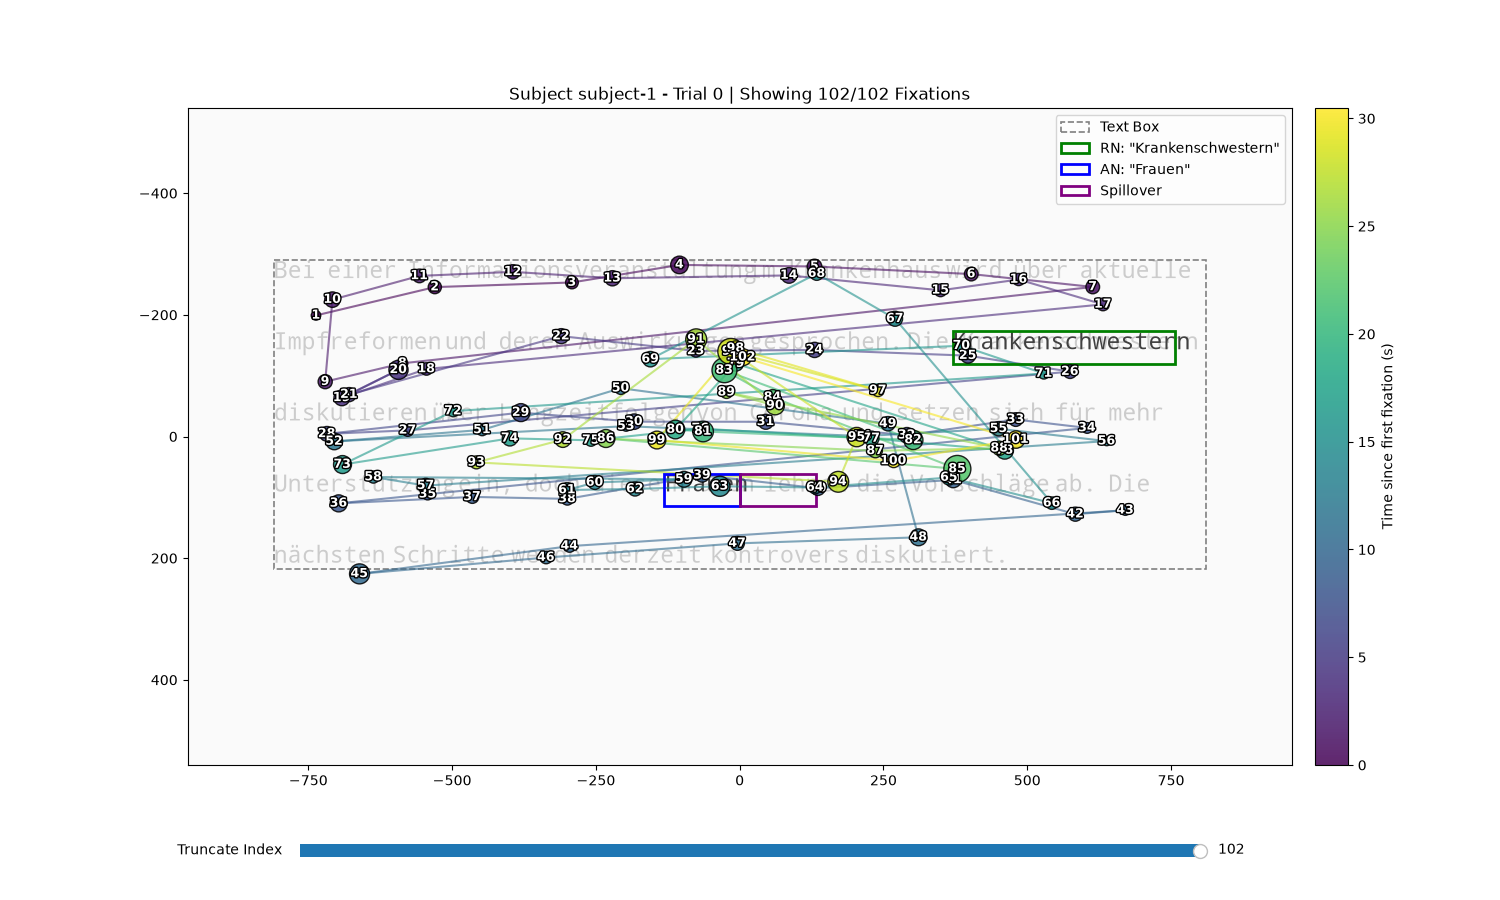

In [7]:
%matplotlib widget
from src.inspection import plot_scanpath_interactive
font_path = io.font_path("DroidSansMono.ttf")

plot_scanpath_interactive(event, fixations, PID, 0,
    config.RESOLUTION, config.FONT_SIZE, font_path)

In [8]:
%matplotlib inline

## Step 3. drift correction (method comparison)

Rebuild the eyekit objects and compare drift methods on one trial


In [9]:
from src.eyekit_helper import create_text_block, create_aoi_boxes, create_seq
from src.visualization import plot_gazepath_eyekit
from src.fixations import mark_truncation

text_df = io.load_split_text(PID)
events  = io.load_checkpoint("events", PID)
coding = io.load_coding(PID)   

text_blocks = create_text_block(text_df, config.TEXT_START, config.RESOLUTION, config.FONT_SIZE, config.LINE_SPACE)
aoi = create_aoi_boxes(events, config.RESOLUTION, config.FONT_SIZE)

fixations_tuncated = mark_truncation(fixations, coding)
seq = create_seq(fixations, truncate=True)

print("trials with fixations:", sorted(seq))


trials with fixations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [10]:
# compare methods on ONE trial -> eyeball the gazepath, note delta/kappa
import os
TRIAL = 6
candidates = [config.DRIFT_METHODS, 'regress', 'merge', 'slice', 'cluster', 'chain', 'warp']
temp_path = f'../plots/temp/{PID}/{TRIAL}/'
os.makedirs(temp_path, exist_ok=True)
plot_gazepath_eyekit(text_blocks[TRIAL], aoi[TRIAL], seq[TRIAL], config.RESOLUTION, f'{temp_path}/drift_original.png')
for m in candidates:
    s = seq[TRIAL].copy()
    #if len(m) > 1:
    d, k = s.snap_to_lines(text_blocks[TRIAL], method=m)
    print(f"{str(m):30s}  delta={d:6.1f}  kappa={k}")
    plot_gazepath_eyekit(text_blocks[TRIAL], aoi[TRIAL], s, config.RESOLUTION, f'{temp_path}/drift_{m}.png')  # shows inline


['chain', 'regress', 'cluster']  delta=  19.6  kappa=0.9681645486702475
regress                         delta=  20.0  kappa=None
merge                           delta=  20.8  kappa=None
slice                           delta=  99.2  kappa=None
cluster                         delta=  19.8  kappa=None
chain                           delta=  19.6  kappa=None
warp                            delta=  93.2  kappa=None


In [11]:
corr = io.load_checkpoint("fixations_corrected", PID)

## Step 4. measures (one subject)

Rebuild corrected sequences from the table and run the eyekit measures


In [12]:
from src.eyekit_helper import seq_from_df
from src.measures import fixation_measures

seq_corr = seq_from_df(corr, y_col="Y_snapped")
info = io.load_subject_info(PID)
results_subj = fixation_measures(seq_corr, aoi, exclusion=set(info.get("exclude") or []))
results_subj.head(9)


,trial_id,aoi_type,n_fixations,first_pass_duration,total_duration,go_past_duration,regressions_in
0,0,rn,4,235,730,11243,0
1,0,an,3,194,877,194,0
2,0,spill,1,168,168,168,0
3,1,rn,0,0,0,0,0
4,1,an,3,160,548,160,1
5,1,spill,1,154,154,154,0
6,2,rn,1,355,355,355,0
7,2,an,1,416,416,416,0
8,2,spill,2,288,469,1273,0
